In [1]:
!pip uninstall -y protobuf tensorflow
!pip -q install faiss-cpu google-generativeai mediapipe==0.10.13 protobuf==4.25.3

Found existing installation: protobuf 5.29.6
Uninstalling protobuf-5.29.6:
  Successfully uninstalled protobuf-5.29.6
Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.9/173.9 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.6/297.6 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf-tf 2.20.0 requires tensorflow==2.20.0, which is not installed.
grain 0.2.18 requires protobuf>=5.28.

In [2]:
import os
import cv2
import faiss
import pickle
import numpy as np
import pandas as pd
import mediapipe as mp

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import google.generativeai as genai

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
import joblib
import faiss

MODELS = "/content/drive/MyDrive/AI_Personal_Stylist/models"

scaler = joblib.load(f"{MODELS}/scaler.pkl")
pca = joblib.load(f"{MODELS}/pca.pkl")
metadata = joblib.load(f"{MODELS}/metadata.pkl")
training_features = joblib.load(f"{MODELS}/training_features.pkl")

index = faiss.read_index(f"{MODELS}/faiss_index.bin")

print("Everything loaded successfully!")

Everything loaded successfully!


In [5]:
DATASETS = "/content/drive/MyDrive/AI_Personal_Stylist/datasets"

fashion_kb = pd.read_excel(
    f"{DATASETS}/fashion_knowledge_base.xlsx"
)

body_metadata = pd.read_csv(
    f"{DATASETS}/body_features_with_metadata.csv"
)

print(fashion_kb.shape)
print(body_metadata.shape)

(300, 9)
(5820, 54)


In [6]:
mp_pose = mp.solutions.pose

pose = mp_pose.Pose(
    static_image_mode=True,
    model_complexity=2,
    min_detection_confidence=0.5
)

In [7]:
from google.colab import files

uploaded = files.upload()

Saving pretty-young-woman-posing-sexy-jeans-shorts-isolated-white-full-length_231208-7970.avif to pretty-young-woman-posing-sexy-jeans-shorts-isolated-white-full-length_231208-7970.avif


True


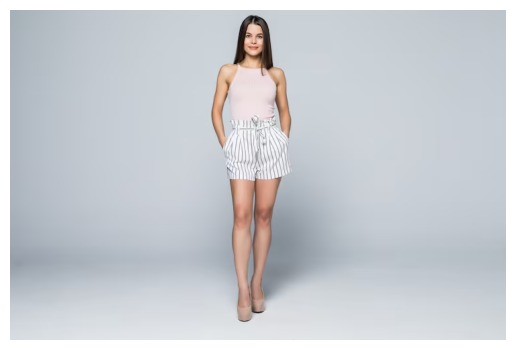

In [9]:
import matplotlib.pyplot as plt
image_path = list(uploaded.keys())[0]
image = cv2.imread(image_path)

rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
result = pose.process(rgb)

print(result.pose_landmarks is not None)
plt.imshow(rgb)
plt.axis("off")
plt.show()

In [10]:
import os

MODEL_PATH = "/content/drive/MyDrive/AI_Personal_Stylist/models"

print("Files in models folder:\n")

for file in os.listdir(MODEL_PATH):
    print(file)

Files in models folder:

scaler.pkl
pca.pkl
category_encoder.pkl
metadata.pkl
training_features.pkl
faiss_index.bin


In [11]:
DATASET_PATH = "/content/drive/MyDrive/AI_Personal_Stylist/datasets"

print("Files in datasets folder:\n")

for file in os.listdir(DATASET_PATH):
    print(file)

Files in datasets folder:

fashion_knowledge_base.csv
fashion_knowledge_base.xlsx
landmarks.csv
features.csv
body_features_with_metadata.csv
knowledge_base.csv


In [12]:
LANDMARKS = {
    "NOSE": 0,

    "LEFT_SHOULDER": 11,
    "RIGHT_SHOULDER": 12,

    "LEFT_ELBOW": 13,
    "RIGHT_ELBOW": 14,

    "LEFT_WRIST": 15,
    "RIGHT_WRIST": 16,

    "LEFT_HIP": 23,
    "RIGHT_HIP": 24,

    "LEFT_KNEE": 25,
    "RIGHT_KNEE": 26,

    "LEFT_ANKLE": 27,
    "RIGHT_ANKLE": 28
}

In [13]:
def distance3d(row, p1, p2):
    x1, y1, z1 = row[f"x_{p1}"], row[f"y_{p1}"], row[f"z_{p1}"]
    x2, y2, z2 = row[f"x_{p2}"], row[f"y_{p2}"], row[f"z_{p2}"]

    return np.sqrt(
        (x2 - x1) ** 2 +
        (y2 - y1) ** 2 +
        (z2 - z1) ** 2
    )

In [14]:
def midpoint3d(row, p1, p2):

    return np.array([
        (row[f"x_{p1}"] + row[f"x_{p2}"]) / 2,
        (row[f"y_{p1}"] + row[f"y_{p2}"]) / 2,
        (row[f"z_{p1}"] + row[f"z_{p2}"]) / 2
    ])

In [15]:
def point_distance(a, b):
    return np.linalg.norm(a - b)

In [16]:
def estimated_height(row):

    shoulder_mid = midpoint3d(row, 11, 12)
    hip_mid = midpoint3d(row, 23, 24)
    knee_mid = midpoint3d(row, 25, 26)
    ankle_mid = midpoint3d(row, 27, 28)

    head = np.array([
        row["x_0"],
        row["y_0"],
        row["z_0"]
    ])

    return (
        point_distance(head, shoulder_mid)
        + point_distance(shoulder_mid, hip_mid)
        + point_distance(hip_mid, knee_mid)
        + point_distance(knee_mid, ankle_mid)
    )

In [17]:
def angle3d(row, a, b, c):

    A = np.array([
        row[f"x_{a}"],
        row[f"y_{a}"],
        row[f"z_{a}"]
    ])

    B = np.array([
        row[f"x_{b}"],
        row[f"y_{b}"],
        row[f"z_{b}"]
    ])

    C = np.array([
        row[f"x_{c}"],
        row[f"y_{c}"],
        row[f"z_{c}"]
    ])

    BA = A - B
    BC = C - B

    cosine = np.dot(BA, BC) / (
        np.linalg.norm(BA) *
        np.linalg.norm(BC)
    )

    cosine = np.clip(cosine, -1, 1)

    return np.degrees(np.arccos(cosine))

In [18]:
def normalize(value, height):

    if height == 0:
        return 0

    return value / height

In [19]:
landmarks = result.pose_landmarks.landmark

row = {}

for i, lm in enumerate(landmarks):

    row[f"x_{i}"] = lm.x
    row[f"y_{i}"] = lm.y
    row[f"z_{i}"] = lm.z
    row[f"v_{i}"] = lm.visibility

landmark_df = pd.DataFrame([row])

print(landmark_df.shape)

landmark_df.head()

(1, 132)


,x_0,y_0,z_0,v_0,x_1,y_1,z_1,v_1,x_2,y_2,...,z_30,v_30,x_31,y_31,z_31,v_31,x_32,y_32,z_32,v_32
0,0.493796,0.097111,-0.307199,0.999805,0.500762,0.083826,-0.283192,0.999662,0.503638,0.084638,...,-0.018818,0.745275,0.498667,0.908768,-0.028868,0.95684,0.478682,0.925981,-0.210239,0.970276


In [20]:
# Get the only row
row = landmark_df.iloc[0]

# ---------- Height ----------
height = estimated_height(row)

if height <= 0:
    raise ValueError("Unable to estimate body height.")

# ---------- Widths ----------
shoulder_width = distance3d(row, 11, 12)
hip_width = distance3d(row, 23, 24)

shoulder_mid = midpoint3d(row, 11, 12)
hip_mid = midpoint3d(row, 23, 24)

torso_length = point_distance(shoulder_mid, hip_mid)

# ---------- Arms ----------
left_upper_arm = distance3d(row, 11, 13)
right_upper_arm = distance3d(row, 12, 14)

left_forearm = distance3d(row, 13, 15)
right_forearm = distance3d(row, 14, 16)

left_arm = left_upper_arm + left_forearm
right_arm = right_upper_arm + right_forearm

# ---------- Legs ----------
left_thigh = distance3d(row, 23, 25)
right_thigh = distance3d(row, 24, 26)

left_calf = distance3d(row, 25, 27)
right_calf = distance3d(row, 26, 28)

left_leg = left_thigh + left_calf
right_leg = right_thigh + right_calf

avg_arm = (left_arm + right_arm) / 2
avg_leg = (left_leg + right_leg) / 2

# ---------- Ratios ----------
shoulder_hip_ratio = shoulder_width / hip_width if hip_width != 0 else 0
torso_leg_ratio = torso_length / avg_leg if avg_leg != 0 else 0

# ---------- Angles ----------
left_elbow_angle = angle3d(row, 11, 13, 15)
right_elbow_angle = angle3d(row, 12, 14, 16)

left_knee_angle = angle3d(row, 23, 25, 27)
right_knee_angle = angle3d(row, 24, 26, 28)

# ---------- Visibility ----------
visibility = [row[f"v_{i}"] for i in range(33)]

feature = {

    "height": height,

    "shoulder_width": normalize(shoulder_width, height),
    "hip_width": normalize(hip_width, height),
    "torso_length": normalize(torso_length, height),

    "left_upper_arm": normalize(left_upper_arm, height),
    "right_upper_arm": normalize(right_upper_arm, height),

    "left_forearm": normalize(left_forearm, height),
    "right_forearm": normalize(right_forearm, height),

    "left_arm": normalize(left_arm, height),
    "right_arm": normalize(right_arm, height),

    "left_thigh": normalize(left_thigh, height),
    "right_thigh": normalize(right_thigh, height),

    "left_calf": normalize(left_calf, height),
    "right_calf": normalize(right_calf, height),

    "left_leg": normalize(left_leg, height),
    "right_leg": normalize(right_leg, height),

    "shoulder_hip_ratio": shoulder_hip_ratio,
    "torso_leg_ratio": torso_leg_ratio,

    "shoulder_height_ratio": normalize(shoulder_width, height),
    "hip_height_ratio": normalize(hip_width, height),
    "torso_height_ratio": normalize(torso_length, height),

    "arm_height_ratio": avg_arm / height,
    "leg_height_ratio": avg_leg / height,

    "arm_leg_ratio": avg_arm / avg_leg if avg_leg != 0 else 0,
    "shoulder_arm_ratio": shoulder_width / avg_arm if avg_arm != 0 else 0,
    "hip_leg_ratio": hip_width / avg_leg if avg_leg != 0 else 0,

    "left_right_arm_ratio": left_arm / right_arm if right_arm != 0 else 0,
    "left_right_leg_ratio": left_leg / right_leg if right_leg != 0 else 0,

    "arm_symmetry": abs(left_arm - right_arm),
    "leg_symmetry": abs(left_leg - right_leg),

    "shoulder_level_diff": abs(row["y_11"] - row["y_12"]),
    "hip_level_diff": abs(row["y_23"] - row["y_24"]),
    "knee_level_diff": abs(row["y_25"] - row["y_26"]),
    "ankle_level_diff": abs(row["y_27"] - row["y_28"]),

    "left_elbow_angle": left_elbow_angle,
    "right_elbow_angle": right_elbow_angle,

    "left_knee_angle": left_knee_angle,
    "right_knee_angle": right_knee_angle,

    "avg_visibility": np.mean(visibility),
    "min_visibility": np.min(visibility),
    "max_visibility": np.max(visibility),

    "visible_landmarks": np.sum(np.array(visibility) > 0.5),

    "pose_score": np.mean(visibility)
}

feature_df = pd.DataFrame([feature])

print(feature_df.shape)

feature_df.head()

(1, 43)


,height,shoulder_width,hip_width,torso_length,left_upper_arm,right_upper_arm,left_forearm,right_forearm,left_arm,right_arm,...,ankle_level_diff,left_elbow_angle,right_elbow_angle,left_knee_angle,right_knee_angle,avg_visibility,min_visibility,max_visibility,visible_landmarks,pose_score
0,0.926187,0.149822,0.1021,0.254584,0.150461,0.135803,0.158381,0.14919,0.308841,0.284994,...,0.015429,104.423445,130.473958,157.259809,148.882385,0.73702,0.116241,0.999984,24,0.73702


In [21]:
import joblib

training_features = joblib.load(
    "/content/drive/MyDrive/AI_Personal_Stylist/models/training_features.pkl"
)

print("Training feature count:", len(training_features))

Training feature count: 43


In [22]:
exclude = ["image_name"]  # if image_name exists

feature_vector = feature_df[training_features]


In [23]:
assert feature_vector.shape[1] == scaler.n_features_in_

In [24]:
scaled = scaler.transform(feature_vector)
embedding = pca.transform(scaled)

print(embedding.shape)

(1, 19)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [25]:
k = 5

distances, indices = index.search(
    embedding.astype("float32"),
    k
)

print("Nearest neighbours:")
print(indices)

print("\nDistances:")
print(distances)

Nearest neighbours:
[[ 577  578  623 4332 4333]]

Distances:
[[4.81367  4.81367  6.018385 6.384125 6.384125]]


In [26]:
metadata = joblib.load(
    "/content/drive/MyDrive/AI_Personal_Stylist/models/metadata.pkl"
)

print(metadata.shape)
metadata.head()

(5820, 6)


,image_name,category_name,style,viewpoint,occlusion,scale
0,122900.jpg,skirt,2,1,1,3
1,122900.jpg,short sleeve top,1,1,1,2
2,170884.jpg,short sleeve dress,1,2,2,3
3,132612.jpg,skirt,0,2,3,1
4,132612.jpg,long sleeve outwear,3,2,2,2


In [27]:
D, I = index.search(embedding.astype(np.float32), k=5)

retrieved = metadata.iloc[I[0]]

print(retrieved.head())

      image_name      category_name  style  viewpoint  occlusion  scale
577   120810.jpg              skirt      0          2          1      1
578   120810.jpg   short sleeve top      3          2          1      1
623   157543.jpg  long sleeve dress      1          2          2      2
4332  010963.jpg             shorts      0          2          1      1
4333  010963.jpg   short sleeve top      1          2          1      2


In [28]:
retrieved[
    [
        "image_name",
        "category_name",
        "style",
        "viewpoint"
    ]
]

,image_name,category_name,style,viewpoint
577,120810.jpg,skirt,0,2
578,120810.jpg,short sleeve top,3,2
623,157543.jpg,long sleeve dress,1,2
4332,010963.jpg,shorts,0,2
4333,010963.jpg,short sleeve top,1,2


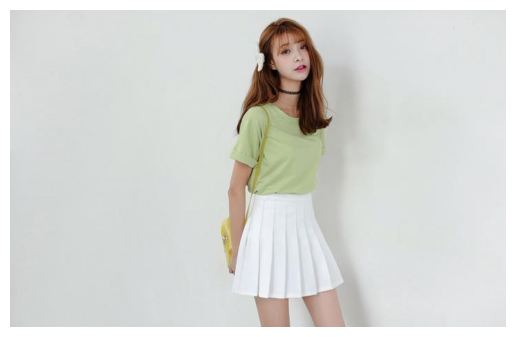

In [29]:
import zipfile
import cv2
import numpy as np

zip_path = "/content/drive/MyDrive/AI_Personal_Stylist/data/train.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    data = z.read("train/image/120810.jpg")   # adjust the internal path if needed

img = cv2.imdecode(np.frombuffer(data, np.uint8), cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

In [30]:
retrieved = (
    retrieved
    .drop_duplicates(subset="image_name")
    .head(5)
)

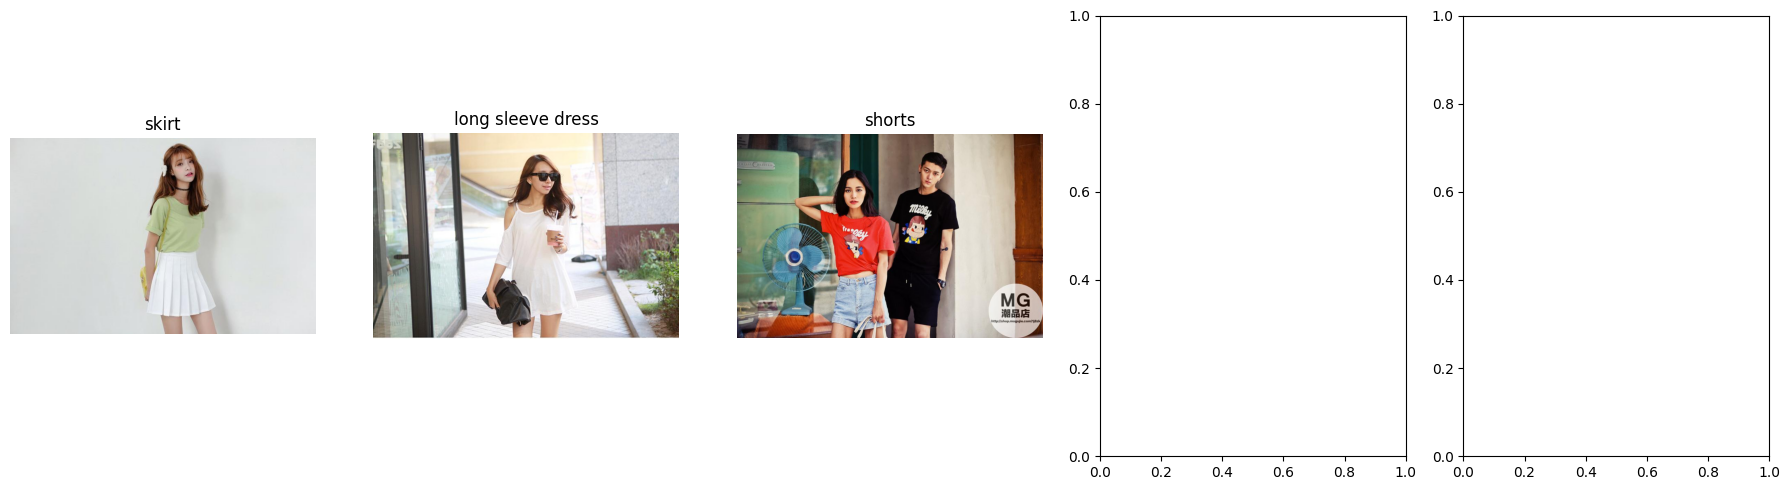

In [31]:
zip_path = "/content/drive/MyDrive/AI_Personal_Stylist/data/train.zip"

fig, axes = plt.subplots(1, 5, figsize=(18,5))

with zipfile.ZipFile(zip_path, "r") as z:

    for ax, (_, row) in zip(axes, retrieved.iterrows()):

        try:
            # Image inside the ZIP
            image_path = f"train/image/{row['image_name']}"

            # Read image bytes
            data = z.read(image_path)

            # Decode image
            img = cv2.imdecode(np.frombuffer(data, np.uint8), cv2.IMREAD_COLOR)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            ax.imshow(img)

        except KeyError:
            ax.text(0.5, 0.5, "Image\nNot Found",
                    ha="center", va="center", fontsize=12)

        ax.set_title(row["category_name"])
        ax.axis("off")

plt.tight_layout()
plt.show()

In [32]:
with zipfile.ZipFile(zip_path, "r") as z:
    names = set(z.namelist())

    for img in retrieved["image_name"]:
        path = f"train/image/{img}"
        print(path, path in names)

train/image/120810.jpg True
train/image/157543.jpg True
train/image/010963.jpg True


In [33]:
print("=" * 50)
print("Top Similar Fashion Examples")
print("=" * 50)

for rank, (_, row) in enumerate(retrieved.iterrows(), start=1):

    print(f"\nRecommendation #{rank}")

    print(f"Image Name : {row['image_name']}")
    print(f"Category   : {row['category_name']}")
    print(f"Style      : {row['style']}")
    print(f"Viewpoint  : {row['viewpoint']}")
    print(f"Scale      : {row['scale']}")
    print(f"Occlusion  : {row['occlusion']}")

    print("-" * 50)

Top Similar Fashion Examples

Recommendation #1
Image Name : 120810.jpg
Category   : skirt
Style      : 0
Viewpoint  : 2
Scale      : 1
Occlusion  : 1
--------------------------------------------------

Recommendation #2
Image Name : 157543.jpg
Category   : long sleeve dress
Style      : 1
Viewpoint  : 2
Scale      : 2
Occlusion  : 2
--------------------------------------------------

Recommendation #3
Image Name : 010963.jpg
Category   : shorts
Style      : 0
Viewpoint  : 2
Scale      : 1
Occlusion  : 1
--------------------------------------------------


In [34]:
fashion_kb = pd.read_excel(
    "/content/drive/MyDrive/AI_Personal_Stylist/datasets/fashion_knowledge_base.xlsx"
)

fashion_kb.head()

,category,body_condition,occasion,season,style,recommended_color,recommendation,avoid,explanation
0,blouse,Narrow shoulders,Date,Autumn,Minimalist,Brown,Boat-neck blouses add shoulder emphasis.,Deep narrow V-necks,Boat-neck blouses add shoulder emphasis. Recom...
1,coat,Petite,Office,Autumn,Formal,Black,Single-breasted coats maintain vertical lines.,Bulky double-breasted coats,Single-breasted coats maintain vertical lines....
2,jeans,Broad shoulders,Business,All,Minimalist,Brown,Mid-rise straight jeans balance the frame.,Very skinny jeans,Mid-rise straight jeans balance the frame. Rec...
3,blazer,Narrow shoulders,Business,Autumn,Elegant,Olive,Structured shoulder blazers add definition.,Unstructured oversized blazers,Structured shoulder blazers add definition. Re...
4,jeans,Petite,Business,Summer,Elegant,White,Slim straight jeans create a longer silhouette.,Excessively wide-leg jeans,Slim straight jeans create a longer silhouette...


In [35]:
categories = retrieved["category_name"].unique().tolist()

print(categories)

['skirt', 'long sleeve dress', 'shorts']


In [36]:
print(fashion_kb.columns.tolist())

['category', 'body_condition', 'occasion', 'season', 'style', 'recommended_color', 'recommendation', 'avoid', 'explanation']


In [37]:
knowledge = fashion_kb[
    fashion_kb["category"].isin(categories)
]

knowledge

,category,body_condition,occasion,season,style,recommended_color,recommendation,avoid,explanation
7,skirt,Short legs,Date,Summer,Casual,White,High-waisted A-line skirts lengthen the legs.,Mid-calf skirts,High-waisted A-line skirts lengthen the legs. ...
13,skirt,Short legs,Casual,All,Formal,Beige,High-waisted A-line skirts lengthen the legs.,Mid-calf skirts,High-waisted A-line skirts lengthen the legs. ...
14,skirt,Short legs,Casual,Summer,Casual,Grey,High-waisted A-line skirts lengthen the legs.,Mid-calf skirts,High-waisted A-line skirts lengthen the legs. ...
22,skirt,Short legs,Casual,Winter,Formal,Beige,High-waisted A-line skirts lengthen the legs.,Mid-calf skirts,High-waisted A-line skirts lengthen the legs. ...
29,skirt,Short legs,Casual,Winter,Smart Casual,Olive,High-waisted A-line skirts lengthen the legs.,Mid-calf skirts,High-waisted A-line skirts lengthen the legs. ...
37,skirt,Short legs,Business,Spring,Elegant,Beige,High-waisted A-line skirts lengthen the legs.,Mid-calf skirts,High-waisted A-line skirts lengthen the legs. ...
47,skirt,Short legs,Business,Autumn,Smart Casual,White,High-waisted A-line skirts lengthen the legs.,Mid-calf skirts,High-waisted A-line skirts lengthen the legs. ...
51,skirt,Short legs,Date,Summer,Casual,Olive,High-waisted A-line skirts lengthen the legs.,Mid-calf skirts,High-waisted A-line skirts lengthen the legs. ...
53,skirt,Short legs,Office,Winter,Elegant,Beige,High-waisted A-line skirts lengthen the legs.,Mid-calf skirts,High-waisted A-line skirts lengthen the legs. ...
62,skirt,Short legs,Party,All,Smart Casual,Grey,High-waisted A-line skirts lengthen the legs.,Mid-calf skirts,High-waisted A-line skirts lengthen the legs. ...


In [38]:
body_shape = feature_df.get("body_shape", pd.Series(["Unknown"])).iloc[0]
confidence = feature_df.get("confidence", pd.Series([0.0])).iloc[0]

body_features = feature_df[
    [
        "height",
        "shoulder_width",
        "hip_width",
        "torso_length",
        "shoulder_hip_ratio",
        "torso_leg_ratio"
    ]
].to_string(index=False)

retrieved_items = "\n".join([
    f"- {row['category_name']} (Style: {row['style']}, Viewpoint: {row['viewpoint']})"
    for _, row in retrieved.iterrows()
])

fashion_rules = knowledge.to_string(index=False)

prompt = f"""
You are an experienced AI Fashion Stylist.

Use the retrieved fashion knowledge and similar examples to provide personalized recommendations.

## User Information

Detected Body Shape:
{body_shape}

Prediction Confidence:
{confidence:.2f}

Body Measurements:
{body_features}

## Similar Fashion Examples Retrieved

{retrieved_items}

## Fashion Knowledge Base

{fashion_rules}

Based on the above information, provide:

1. Body shape analysis
2. Why this body shape suits certain clothing
3. Best clothing recommendations (tops, bottoms, dresses, outerwear)
4. Clothing to avoid
5. Recommended colors
6. Recommended fabrics
7. Seasonal outfit ideas (Summer, Winter, Monsoon)
8. Footwear recommendations
9. Accessories
10. Styling tips to create a balanced silhouette

Keep the response friendly, practical, personalized, and easy to read. Use bullet points where appropriate.
"""

In [39]:
from google import genai
from google.colab import userdata

API_KEY = userdata.get("GOOGLE_API_KEY")

client = genai.Client(api_key=API_KEY)

response = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=prompt
)

print(response.text)

Hello there! As your personal AI Fashion Stylist, I have analyzed your unique body measurements and proportions to craft a styling guide tailored just for you. 

Even though your general body shape label came back as "Unknown" due to a low prediction confidence, your exact measurements tell a very clear and beautiful story! Let’s break down your proportions and build your perfect wardrobe.

---

### 1. Body Shape Analysis
Based on your measurements, you have two key defining physical characteristics:
*   **Inverted Triangle Tendency:** Your shoulder-to-hip ratio is **1.47**, which means your shoulders are significantly broader than your hips. This gives you a strong, athletic, and regal upper body.
*   **Torso-to-Leg Ratio (0.54) & Leg-Lengthening Focus:** Your measurements and our fashion database indicate that balancing your vertical proportions is key. We want to focus on **visually elongating your legs** and defining your waist to create a perfectly balanced, harmonious frame.

---

In [40]:
def recommend_outfit(image_path):

    return response.text

In [41]:
recommend_outfit(image_path)

'Hello there! As your personal AI Fashion Stylist, I have analyzed your unique body measurements and proportions to craft a styling guide tailored just for you. \n\nEven though your general body shape label came back as "Unknown" due to a low prediction confidence, your exact measurements tell a very clear and beautiful story! Let’s break down your proportions and build your perfect wardrobe.\n\n---\n\n### 1. Body Shape Analysis\nBased on your measurements, you have two key defining physical characteristics:\n*   **Inverted Triangle Tendency:** Your shoulder-to-hip ratio is **1.47**, which means your shoulders are significantly broader than your hips. This gives you a strong, athletic, and regal upper body.\n*   **Torso-to-Leg Ratio (0.54) & Leg-Lengthening Focus:** Your measurements and our fashion database indicate that balancing your vertical proportions is key. We want to focus on **visually elongating your legs** and defining your waist to create a perfectly balanced, harmonious f